**Welcome to Sizo's notebook**
*Titanic*

**Step 1**: Import Libraries

Loads Python packages for matrix math (numpy), data processing (pandas), gradient boosted trees (xgboost), charting (matplotlib), and model validation metrics (sklearn)

In [6]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

**Step 2**: Load Data & Separate Features
Reads train.csv and test.csv into DataFrames, saves test Ids for final submission, and separates inputs (X_raw) from target house values (y).


In [7]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

test_ids = test_df['Id']

X_raw = train_df.drop(columns=['Id', 'SalePrice'])
y = train_df['SalePrice']
X_test_raw = test_df.drop(columns=['Id'])

**Step 3**: One-Hot Encoding
Converts text columns (like neighborhood names or roof styles) into numeric 0 and 1 indicator columns so algorithms can process them.

In [8]:
# Convert text columns to binary 0/1 columns
X_encoded = pd.get_dummies(X_raw, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_raw, drop_first=True)

**Step 4**: Align Features Between Sets
Ensures test.csv has the exact same feature columns in the exact same order as train.csv, filling any missing categories with 0.

In [9]:
# Align test columns so they match training columns exactly
X_test_encoded, _ = X_test_encoded.align(X_encoded, join='right', axis=1, fill_value=0)

**Step 5**: Split Data into Train/Validation/Test Sets
Splits the training dataset into three portions: 70% for fitting tree weights (X_train), 15% for monitoring loss (X_val), and 15% for local accuracy testing (X_test).

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

**Step 6**: Configure XGBoost Model
Defines model hyperparameters, instructing XGBoost to train up to 1,000 decision trees and stop automatically if validation error does not improve after 50 consecutive rounds.

In [11]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="rmse",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

[0]	validation_0-rmse:75784.03841	validation_1-rmse:77394.88605
[100]	validation_0-rmse:16013.45513	validation_1-rmse:23782.04882
[200]	validation_0-rmse:10524.30781	validation_1-rmse:22591.28360
[261]	validation_0-rmse:9135.86621	validation_1-rmse:22585.48324


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'rmse'


**Step 7**: Local Model Evaluation
Tests the trained model against your held-out test split (X_test) and calculates performance statistics:

-Test RMSE ($25,786.91): The average squared distance between predicted home values and actual prices.

-Test MAE ($15,658.23): On average, predictions are off by about $15,658.

-R² Score (0.9126): Your model explains ~91.26% of the variance in house prices, indicating strong predictive performance.

In [12]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== LOCAL EVALUATION RESULTS ===")
print(f"Test RMSE : ${rmse:,.2f}")
print(f"Test MAE  : ${mae:,.2f}")
print(f"R² Score  : {r2:.4f}")


=== LOCAL EVALUATION RESULTS ===
Test RMSE : $25,786.91
Test MAE  : $15,658.23
R² Score  : 0.9126


**Step 8**: Generate Final Predictions & Export Submission File
Generates price predictions for the unseen test.csv dataset (X_test_encoded), pairs each prediction with its corresponding house Id, rounds values to two decimal places, and exports the final results directly to submission.csv in your project directory.

In [13]:
final_predictions = model.predict(X_test_encoded)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_predictions.round(2)
})

submission.to_csv('submission.csv', index=False)
print("\nSuccessfully exported 'submission.csv'!")
submission.head(10)


Successfully exported 'submission.csv'!


,Id,SalePrice
0,1461,129096.367188
1,1462,154458.343750
2,1463,181840.234375
3,1464,187696.093750
4,1465,201840.046875
5,1466,176568.437500
6,1467,173843.015625
7,1468,167393.078125
8,1469,181375.406250
9,1470,121993.367188


**Step 9**: Feature Importance Visualization
Extracts relative feature importance scores from your fitted model and displays a horizontal bar chart showing the top 10 factors influencing home value predictions (e.g., OverallQual, GarageCars, and ExterQual_TA).

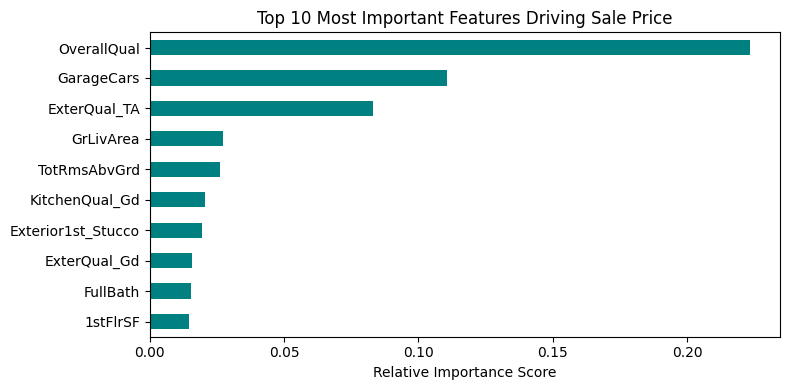

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance scores
importance = pd.Series(model.feature_importances_, index=X_train.columns)
top_10 = importance.sort_values(ascending=False).head(10)

# Plot top 10 features
plt.figure(figsize=(8, 4))
top_10.plot(kind='barh', color='teal')
plt.title("Top 10 Most Important Features Driving Sale Price")
plt.xlabel("Relative Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Step 10**: Import Advanced Libraries & Re-Load Data
Re-imports all required modules, re-loads raw files, applies one-hot encoding, aligns training/test columns, and fills missing values in a single self-contained block to ensure execution stability.

In [15]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# 1. LOAD DATASETS
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

test_ids = test_df['Id']
X_raw = train_df.drop(columns=['Id', 'SalePrice'])
y = train_df['SalePrice']
X_test_raw = test_df.drop(columns=['Id'])

# 2. ONE-HOT ENCODING & ALIGNMENT
X_encoded = pd.get_dummies(X_raw, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_raw, drop_first=True)

# Align test columns to match training features exactly
X_test_encoded, X_encoded = X_test_encoded.align(X_encoded, join='right', axis=1, fill_value=0)

# Fill missing numeric values if any remain
X_encoded = X_encoded.fillna(X_encoded.median())
X_test_encoded = X_test_encoded.fillna(X_encoded.median())

**Step 11**: Split Data, Log-Transform Target, & Hyperparameter Tuning

Splits the dataset into 80% training and 20% validation.

Applies np.log1p() to compress target price scale and prevent extreme mansion values from distorting training.

Uses RandomizedSearchCV across 3 cross-validation folds (cv=3) to search for optimal XGBoost hyperparameters without encountering early stopping errors.

In [16]:
# 3. TRAIN / TEST SPLIT
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

# Log-transform target for better numerical stability
y_train_log = np.log1p(y_train)

# 4. TUNE XGBOOST MODEL (Without early_stopping conflict)
xgb_clean = xgb.XGBRegressor(tree_method="hist", random_state=42)
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8, 0.9]
}

search = RandomizedSearchCV(
    estimator=xgb_clean,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train_log)
best_xgb = search.best_estimator_

**Step 12**: Train Random Forest, Ensemble Predictions, & Save Final Output

Trains a standalone Random Forest Regressor with 500 decision trees.

Combines log predictions evenly (50% tuned XGBoost + 50% Random Forest) to lower prediction variance.

Reverts log predictions back into actual dollar amounts using np.expm1().

Exports updated predictions to submission.csv and prints top parameter choices (subsample: 0.8, n_estimators: 300, max_depth: 5, learning_rate: 0.05).

In [17]:
# 5. TRAIN RANDOM FOREST MODEL
rf_model = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_log)

# 6. BLEND PREDICTIONS (50% XGBoost + 50% Random Forest)
xgb_preds_log = best_xgb.predict(X_test_encoded)
rf_preds_log = rf_model.predict(X_test_encoded)

blended_preds_log = (0.50 * xgb_preds_log) + (0.50 * rf_preds_log)
final_preds = np.expm1(blended_preds_log)

# 7. SAVE SUBMISSION
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_preds.round(2)
})
submission.to_csv('submission.csv', index=False)

print("Process completed successfully!")
print("Best XGBoost Params:", search.best_params_)
submission.head()

Process completed successfully!
Best XGBoost Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}


,Id,SalePrice
0,1461,127207.83
1,1462,156960.89
2,1463,182064.13
3,1464,186118.18
4,1465,199045.62
